# Raw data profile — `dags/energy_data.csv`

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("../dags/energy_data.csv")
df.shape

(2975, 4)

In [11]:
df.head()

,Timestamp,Price,Volume,Sell_Buy
0,2024-01-01 00:02:22+01:00,27.25,1125.0,SELL
1,2024-01-01 00:03:08+01:00,55.96,882.0,sell
2,2024-01-01 00:03:48+01:00,91.00,504.0,buy
3,2024-01-01 00:03:52+01:00,23.57,979.0,buy
4,2024-01-01 00:21:59+01:00,50.29,1934.0,sell


In [14]:
df.dtypes

Timestamp        str
Price        float64
Volume       float64
Sell_Buy         str
dtype: object

In [13]:
df.describe(include="all")

,Timestamp,Price,Volume,Sell_Buy
count,2975,2916.000000,2924.000000,2975
unique,2963,NaN,NaN,6
top,2024-01-01 01:02:45+00:00,NaN,NaN,Buy
freq,2,NaN,NaN,555
mean,NaN,91.243741,1439.815321,NaN
std,NaN,317.996683,3845.413675,NaN
min,NaN,20.090000,50.000000,NaN
25%,NaN,41.107500,549.750000,NaN
50%,NaN,61.110000,1042.000000,NaN
75%,NaN,80.885000,1520.250000,NaN


In [15]:
df.isna().sum()

Timestamp     0
Price        59
Volume       51
Sell_Buy      0
dtype: int64

In [16]:
df.nunique()

Timestamp    2963
Price        2456
Volume       1557
Sell_Buy        6
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

### Remarks:

Timestamp column parsed as string, and gap between the mean and median for Volume and Price column suggests a right skewed distribution. 6 unique values for buy and sell

## Timestamp

In [57]:
df["Timestamp"].head(10).tolist()

['2024-01-01 00:02:22+01:00',
 '2024-01-01 00:03:08+01:00',
 '2024-01-01 00:03:48+01:00',
 '2024-01-01 00:03:52+01:00',
 '2024-01-01 00:21:59+01:00',
 '2024-01-01 00:25:10+01:00',
 '2024-01-01 00:32:00+01:00',
 '2024-01-01 00:32:47+01:00',
 '2024-01-01 00:36:26+01:00',
 '2024-01-01 00:40:09+01:00']

In [19]:
df["Timestamp"].str.len().value_counts()

Timestamp
25    2975
Name: count, dtype: int64

In [20]:
df["Timestamp"].str[-6:].value_counts()

Timestamp
+00:00    2367
+01:00     608
Name: count, dtype: int64

In [21]:
df["Timestamp"].str[:10].value_counts().sort_index()

Timestamp
2024-01-01    1000
2024-01-02    1000
2024-01-03     974
2024-01-04       1
Name: count, dtype: int64

In [22]:
ts = pd.to_datetime(df["Timestamp"], utc=True)
ts.min(), ts.max(), ts.max() - ts.min()

(Timestamp('2023-12-31 23:02:22+0000', tz='UTC'),
 Timestamp('2024-01-03 23:02:13+0000', tz='UTC'),
 Timedelta('2 days 23:59:51'))

In [23]:
ts.dt.date.value_counts().sort_index()

Timestamp
2023-12-31      10
2024-01-01     995
2024-01-02    1004
2024-01-03     966
Name: count, dtype: int64

In [24]:
ts.dt.hour.value_counts().sort_index()

Timestamp
0     121
1     137
2     129
3     140
4     117
5     120
6     115
7     118
8     150
9     130
10    131
11     98
12    123
13    120
14    126
15    131
16    111
17    132
18    137
19    135
20    111
21    138
22    112
23     93
Name: count, dtype: int64

Text(0, 0.5, 'rows per hour')

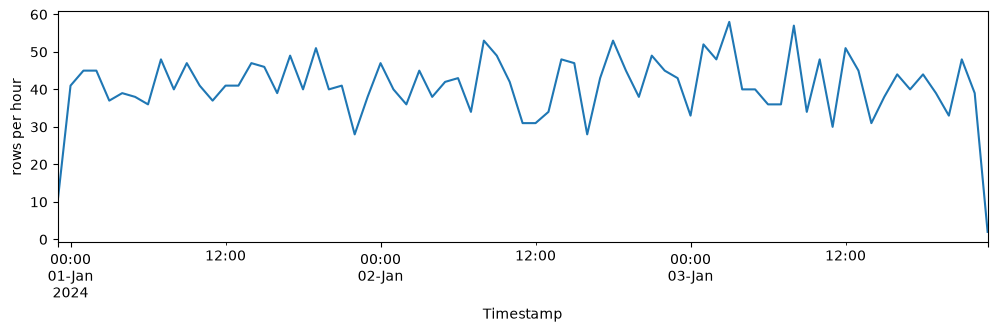

In [27]:
ts.dt.floor("1h").value_counts().sort_index().plot(figsize=(12, 3))
plt.ylabel("rows per hour")

### Remarks:

Two different timezones for the timestamp column, about 3 days of data.

## Price

In [58]:
df.Price.isnull().sum()

np.int64(59)

In [28]:
df["Price"].describe()

count    2916.000000
mean       91.243741
std       317.996683
min        20.090000
25%        41.107500
50%        61.110000
75%        80.885000
max      4883.990000
Name: Price, dtype: float64

In [29]:
df["Price"].quantile([0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1])

0.00      20.0900
0.01      20.8730
0.05      23.6450
0.25      41.1075
0.50      61.1100
0.75      80.8850
0.95      96.9325
0.99    1267.2455
1.00    4883.9900
Name: Price, dtype: float64

In [30]:
(df["Price"] <= 0).sum()

np.int64(0)

In [33]:
q1, q3 = df["Price"].quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
lo, hi

(-18.558749999999982, 140.55124999999998)

In [34]:
price_outliers = df[(df["Price"] < lo) | (df["Price"] > hi)]
len(price_outliers)

32

In [35]:
price_outliers.sort_values("Price")

,Timestamp,Price,Volume,Sell_Buy
1099,2024-01-02 02:20:05+00:00,1082.05,299.0,sell
2653,2024-01-03 15:10:16+00:00,1106.40,1953.0,Buy
2637,2024-01-03 14:32:38+00:00,1295.63,138.0,BUY
2425,2024-01-03 09:34:32+00:00,1306.83,262.0,sell
798,2024-01-01 18:45:39+00:00,1500.79,257.0,sell
2630,2024-01-03 14:16:09+00:00,1608.04,686.0,sell
1149,2024-01-02 03:26:36+00:00,1689.52,172.0,sell
2329,2024-01-03 07:26:13+00:00,1690.85,745.0,buy
1133,2024-01-02 04:06:19+01:00,1751.09,1686.0,Buy
1914,2024-01-02 21:53:46+00:00,1874.27,637.0,BUY


### Remarks:

59 rows without a price and about 1% are outliers

## Volume

In [59]:
df.Volume.isnull().sum()

np.int64(51)

In [36]:
df["Volume"].describe()

count     2924.000000
mean      1439.815321
std       3845.413675
min         50.000000
25%        549.750000
50%       1042.000000
75%       1520.250000
max      49970.000000
Name: Volume, dtype: float64

In [37]:
df["Volume"].quantile([0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1])

0.00       50.00
0.01       73.00
0.05      151.00
0.25      549.75
0.50     1042.00
0.75     1520.25
0.95     1925.00
0.99    21569.39
1.00    49970.00
Name: Volume, dtype: float64

In [38]:
(df["Volume"] <= 0).sum()

np.int64(0)

In [40]:
(df["Volume"] % 1 == 0).value_counts()

Volume
True     2924
False      51
Name: count, dtype: int64

In [43]:
df[df["Volume"] % 1 != 0]

,Timestamp,Price,Volume,Sell_Buy
15,2024-01-01 00:08:57+00:00,52.63,NaN,BUY
17,2024-01-01 00:10:55+00:00,58.81,NaN,SELL
58,2024-01-01 01:07:43+00:00,84.94,NaN,BUY
62,2024-01-01 01:17:15+00:00,42.51,NaN,Buy
96,2024-01-01 03:00:14+01:00,62.75,NaN,buy
130,2024-01-01 03:40:58+01:00,50.02,NaN,Sell
154,2024-01-01 03:20:29+00:00,85.80,NaN,BUY
202,2024-01-01 04:35:37+00:00,69.17,NaN,BUY
210,2024-01-01 04:46:55+00:00,31.74,NaN,Buy
218,2024-01-01 05:07:07+00:00,72.33,NaN,Sell


In [62]:
q1, q3 = df["Volume"].quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
lo, hi

(-906.0, 2976.0)

In [63]:
price_outliers = df[(df["Price"] < lo) | (df["Price"] > hi)]
len(price_outliers)

16

### Remarks:

Only contains integers and 51 rows with missing volume, and about 0.5% are outliers. 

## Sell_Buy

In [44]:
df["Sell_Buy"].value_counts(dropna=False)

Sell_Buy
Buy     555
Sell    505
buy     498
sell    495
SELL    467
BUY     455
Name: count, dtype: int64

In [45]:
df["Sell_Buy"].str.strip().str.lower().value_counts(dropna=False)

Sell_Buy
buy     1508
sell    1467
Name: count, dtype: int64

### Remarks:

The unique values for Sell_Buy are largely due to different Capitalisation.

## Across columns

In [47]:
side = df["Sell_Buy"].str.strip().str.lower()
df.groupby(side)[["Price", "Volume"]].agg(["count", "mean", "median", "std", "min", "max"]).round(2)

Price                                        Volume                   \
         count    mean median     std    min      max  count     mean  median   
Sell_Buy                                                                        
buy       1479  103.28  61.31  387.87  20.14  4883.99   1481  1423.80  1028.0   
sell      1437   78.85  60.83  223.88  20.09  4511.58   1443  1456.25  1049.0   

                                  
              std   min      max  
Sell_Buy                          
buy       3750.29  51.0  49970.0  
sell      3941.89  50.0  49175.0

In [50]:
df["Price"].corr(df["Volume"])

np.float64(-0.0051185830355827576)

Text(0, 0.5, 'Price')

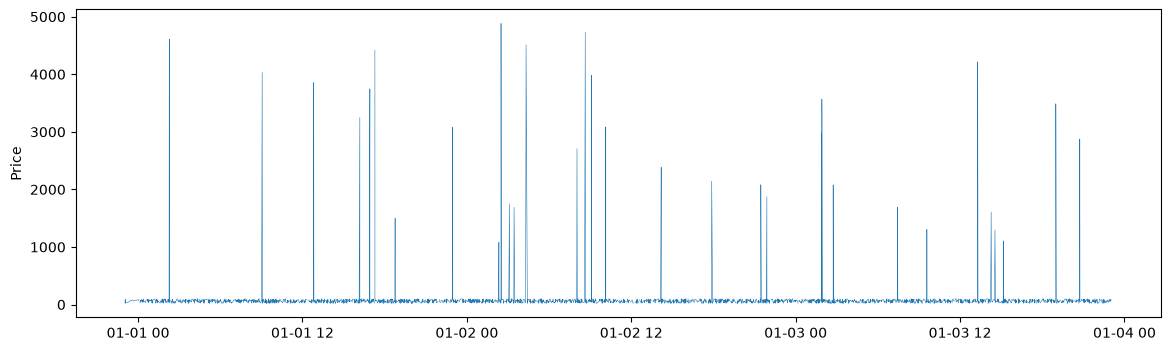

In [53]:
plt.figure(figsize=(14, 4))
plt.plot(t["ts"], t["price"], lw=0.4)
plt.ylabel("Price")

Text(0, 0.5, 'mean price per hour')

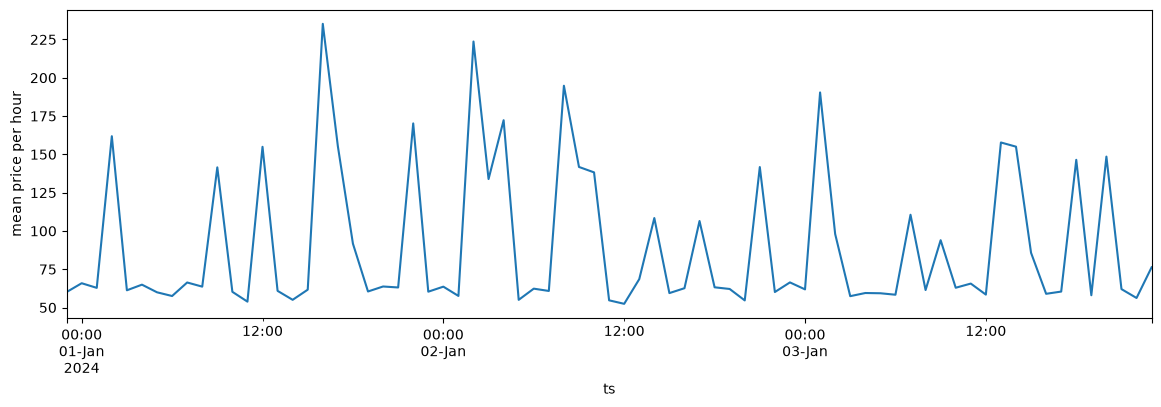

In [54]:
t.set_index("ts")["price"].resample("1h").mean().plot(figsize=(14, 4))
plt.ylabel("mean price per hour")

Text(0, 0.5, 'mean price per hour')

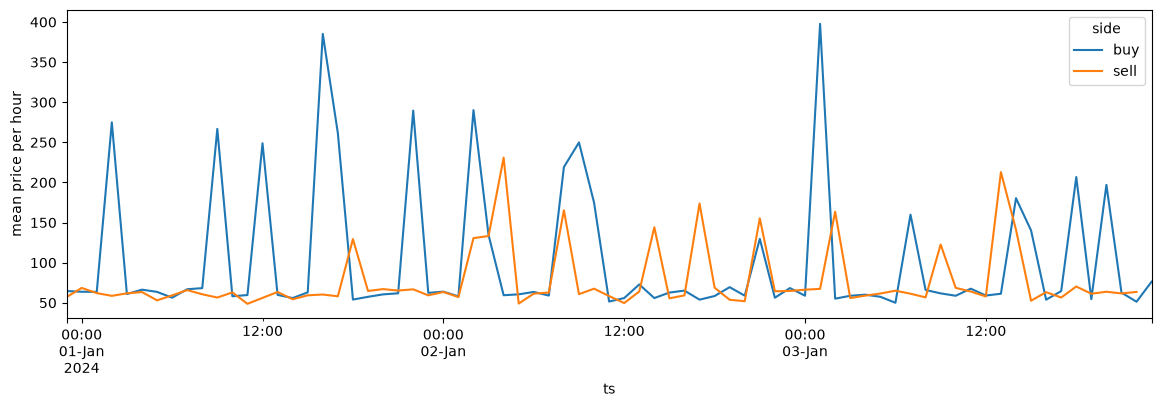

In [56]:
t.set_index("ts").groupby("side")["price"].resample("1h").mean().unstack("side").plot(figsize=(14, 4))
plt.ylabel("mean price per hour")

### Remarks:

The spikes occurs regularly and looks to be a projection of the underlying pattern.